In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

In [16]:
df_train = pd.read_csv('./data/train.csv')
df_test = pd.read_csv('./data/test.csv')

In [3]:
df_train.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [4]:
print(df_train.shape)
print(df_train.info())
print(df_train.describe())

(577347, 12)
<class 'pandas.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  str    
 10  galaxy_population  577347 non-null  str    
 11  class              577347 non-null  str    
dtypes: float64(8), int64(1), str(3)
memory usage: 52.9 MB
None
                 id          alpha          delta              u  \
count  577347.00000  577347.000000  577347.000000  577347.000000   
m

In [5]:
print(df_train.isnull().sum())

id                   0
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
class                0
dtype: int64


In [6]:
print(df_train['class'].unique())

idx = df_train['class'].unique()

le = LabelEncoder()
df_train['class'] = le.fit_transform(df_train['class'])

print(df_train['class'].head())

<StringArray>
['GALAXY', 'QSO', 'STAR']
Length: 3, dtype: str
0    0
1    0
2    1
3    0
4    0
Name: class, dtype: int64


<Axes: >

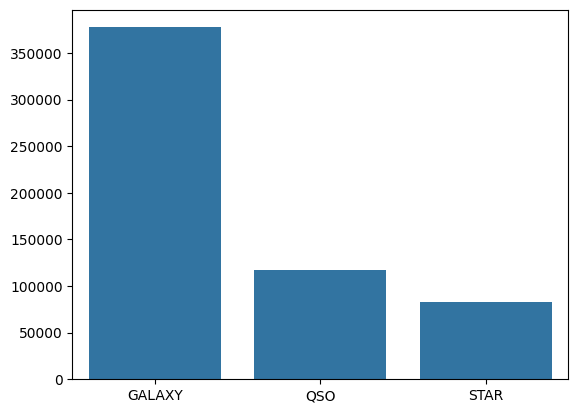

In [7]:
counts = df_train['class'].value_counts()
sns.barplot(x=idx, y=counts.values)

In [8]:
num_cols = df_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df_train.select_dtypes(include=['str']).columns

print("Numerical columns: ", num_cols.tolist())
print("Categorical columns: ", cat_cols.tolist())

Numerical columns:  ['id', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'class']
Categorical columns:  ['spectral_type', 'galaxy_population']


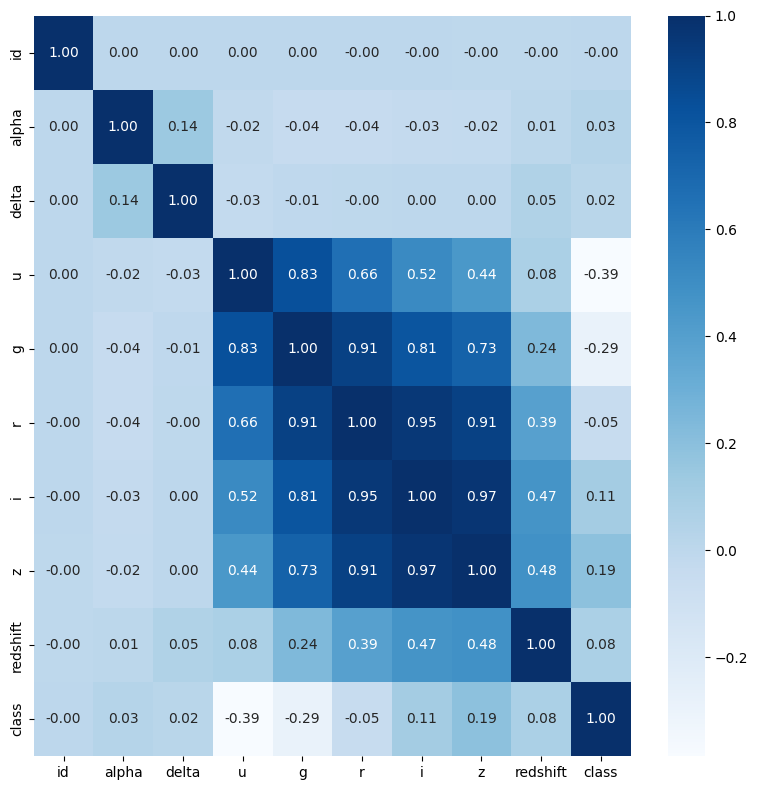

In [9]:
cm = df_train[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    ax=ax
)

plt.tight_layout()
plt.show()

In [10]:
X = df_train.drop('class', axis=1)
y = df_train['class']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['str']).columns

print("Numerical columns: ", num_cols.tolist())
print("Categorical columns: ", cat_cols.tolist())

Numerical columns:  ['id', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
Categorical columns:  ['spectral_type', 'galaxy_population']


### Pipeline

In [12]:
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [13]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(random_state=42))
])

In [14]:
rf_pipeline.fit(X_train, y_train)

y_train_pred = rf_pipeline.predict(X_train)
y_valid_pred = rf_pipeline.predict(X_valid)


In [15]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_valid, y_valid_pred)

print(f"Train accuracy: {train_acc:.2f}")
print(f"Test accuracy: {test_acc:.2f}")

Train accuracy: 1.00
Test accuracy: 0.96
